# Laboratorio 2 — Regresión Lineal Multivariable
### Mollinedo Siles Renzo Sebastian

---

## Descripción del trabajo

En este laboratorio se implementan **tres modelos de regresión** para predecir la cantidad de comentarios que recibirá una publicación de blog en las próximas 24 horas, utilizando el dataset **BlogFeedback** (UCI Machine Learning Repository).

### Dataset
- **Fuente:** [BlogFeedback Data Set — UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/BlogFeedback)
- **Ejemplos de entrenamiento:** 52,397
- **Características:** 280
- **Variable objetivo (label):** número de comentarios en las próximas 24 horas

### Modelos implementados
1. **Regresión Lineal Multivariable** — Descenso por el Gradiente
2. **Regresión Polinómica** — Descenso por el Gradiente con términos cuadráticos
3. **Ecuación Normal** — Solución analítica directa


### Importación de librerías y carga del dataset

Utilizamos pandas para procesar el dataset blogData_train.csv. Dado que el archivo no tiene encabezados, los cargamos directamente

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/Datasets/blogfeedback/blogData_train.csv'

df = pd.read_csv(path, header=None)

print("Shape:", df.shape)

X = df.iloc[:,0:280].values
y = df.iloc[:,280].values

m = len(y)

print("Ejemplos:", m)
print("Features:", X.shape[1])

#Ya que muchas columnas son de puros 0 ignoraremos estas
zero_ratio = np.mean(X == 0, axis=0)

useful_features = zero_ratio < 0.95

X = X[:, useful_features]

print("Features después de eliminar ceros:", X.shape[1])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (52397, 281)
Ejemplos: 52397
Features: 280
Features después de eliminar ceros: 111


### División entrenamiento / validación

In [55]:
train_size = int(0.8 * m)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:]
y_val = y[train_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (41917, 111)
Validation: (10480, 111)


### Preprocesamiento: Normalización de Características
Es fundamental para que el Descenso por el Gradiente converja en un tiempo razonable, especialmente con 280 variables.

In [56]:
def featureNormalize(X):

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

Aplicamos normalización al set de entrenamiento.

In [57]:
X_norm, mu, sigma = featureNormalize(X_train)

m_train = X_norm.shape[0]

# añadir columna de unos
X_ready = np.concatenate([np.ones((m_train,1)), X_norm], axis=1)

### Modelo 1: Regresión Lineal Multivariable (Descenso por el Gradiente)
Función de costo y Descenso por el gradiente

In [58]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    J_history = []
    for i in range(num_iters):
        error = np.dot(X, theta) - y
        theta = theta - (alpha/m) * np.dot(X.T, error)
        J_history.append(computeCostMulti(X,y,theta))

    return theta, J_history

### Entrenamiento modelo 1 (Regresión lineal)

Theta aprendido: [ 7.7621956   1.00457806  1.26910259 -0.42107857 -0.39645054  1.33960355
  1.98554015  1.34161532 -0.19131252  3.82322183]


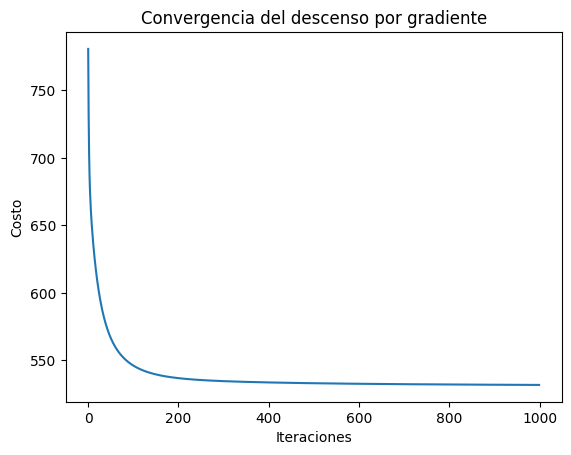

In [59]:
theta = np.zeros(X_ready.shape[1])

alpha = 0.01
iters = 1000

theta_grad, J_history = gradientDescentMulti(X_ready, y_train, theta, alpha, iters)

print("Theta aprendido:", theta_grad[:10])

plt.figure()
plt.plot(J_history)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Convergencia del descenso por gradiente")
plt.show()

### Modelo 2: Regresión Polinómica
Debido a la alta dimensionalidad ($n=280$), realizar una expansión de grado 2 sobre todas las variables generaría ~40,000 características, lo cual es ineficiente. Para este ejercicio, seleccionamos las 10 características con mayor correlación con el objetivo para aplicar el término cuadrático.

### Selección de features para modelo polinómico

In [60]:
correlations = df.corr().iloc[280, 0:280].abs().sort_values(ascending=False)

top_features_idx = correlations.index[:10]

X_poly = df.iloc[:, top_features_idx].values
y_poly = y


### Expansión polinómica manual (grado 2)

In [61]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly_exp = poly.fit_transform(X_poly)

### Normalizamos

In [62]:
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly_exp)

m_poly = X_poly_norm.shape[0]

X_poly_ready = np.concatenate([np.ones((m_poly,1)), X_poly_norm], axis=1)

### Entrenamiento

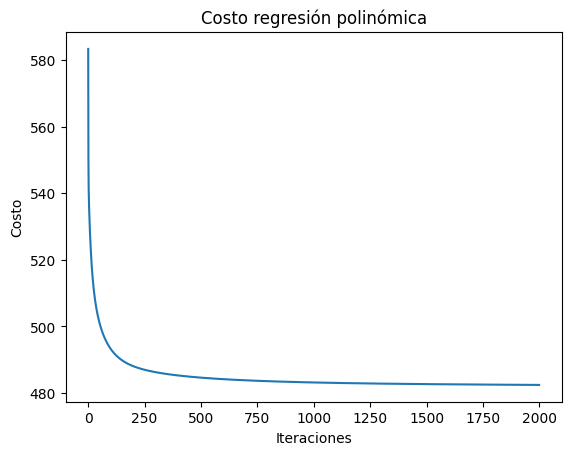

In [63]:
theta_poly = np.zeros(X_poly_ready.shape[1])

theta_poly, J_poly = gradientDescentMulti(
    X_poly_ready,
    y_poly,
    theta_poly,
    0.01,
    2000
)

plt.figure()
plt.plot(J_poly)
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Costo regresión polinómica")
plt.show()

### Modelo 3: Ecuación de la Normal
Este método calcula $\theta$ analíticamente sin necesidad de iteraciones ni normalización.

In [64]:
def normalEqn(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y


# Es necesario añadir la columna de unos al X original (sin normalizar)
X_normal = np.concatenate([np.ones((m,1)), X], axis=1)
theta_normal = normalEqn(X_normal, y)

print("Theta normal:", theta_normal[:10])

Theta normal: [ 3.84366121e+00 -6.76295300e-01  3.57866639e-01 -4.91825948e-03
 -8.66794121e-04  6.93227398e-02  1.26254811e+00 -6.85840397e-01
  2.44509145e-02 -6.84909086e-02]


### Validación y Predicciones (Efectividad)
Realizamos 100 predicciones comparando los resultados de los modelos con los valores reales del dataset.

In [65]:
X_test = X_val[:100]
y_real = y_val[:100]

### Predicción modelo gradiente

In [66]:
X_test_norm = (X_test - mu) / sigma

X_test_ready = np.concatenate([np.ones((100,1)), X_test_norm], axis=1)

pred_grad = X_test_ready @ theta_grad

### Predicción polinómica

In [67]:
X_test_poly = X_test[:, top_features_idx]

X_test_poly_exp = poly.transform(X_test_poly)

X_test_poly_norm = (X_test_poly_exp - mu_poly) / sigma_poly

X_test_poly_ready = np.concatenate([np.ones((100,1)), X_test_poly_norm], axis=1)

pred_poly = X_test_poly_ready @ theta_poly

### Predicción ecuación normal

In [68]:
X_test_normal = np.concatenate([np.ones((100,1)), X_test], axis=1)

pred_normal = X_test_normal @ theta_normal

Algunas predicciones Realizadas

In [69]:
for i in range(100):

    print("Real:", y_real[i],
          "Grad:", pred_grad[i],
          "Poly:", pred_poly[i],
          "Normal:", pred_normal[i])

Real: 0.0 Grad: -3.597562218677861 Poly: 4.985412715710502 Normal: -2.7555463116178376
Real: 0.0 Grad: -3.0420000073642344 Poly: 8.881393840885448 Normal: -2.769155863963611
Real: 0.0 Grad: -7.472212171594642 Poly: 9.049843854991153 Normal: -5.990115155975913
Real: 0.0 Grad: 0.7925967333809129 Poly: -0.33129003351975705 Normal: 0.7500956130280274
Real: 0.0 Grad: 7.245786904567244 Poly: -1.1958762569901487 Normal: 5.578563753303781
Real: 0.0 Grad: 1.148555276045591 Poly: -0.15860790622506715 Normal: 0.6932081558666838
Real: 0.0 Grad: -2.8677111238568083 Poly: 3.7914502208091134 Normal: -2.190758971861018
Real: 0.0 Grad: 3.585479047329527 Poly: 2.9362686933142426 Normal: 2.637709168414737
Real: 0.0 Grad: -2.511752581192129 Poly: 3.9622514089087 Normal: -2.2476464290223617
Real: 0.0 Grad: -5.581175166806166 Poly: 7.869047934455492 Normal: -4.492657070636838
Real: 0.0 Grad: 0.8720150043801701 Poly: 7.02327110293614 Normal: 0.33581106963891744
Real: 0.0 Grad: -5.225216624141487 Poly: 8.0379